# **Evaluación con End-Point-Error (EPE) de Lucas-Kanade**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
IMG1_PATH = "flying_chairs/00001_img1.ppm"
IMG2_PATH = "flying_chairs/00001_img2.ppm"
FLOW_GT_PATH = "flying_chairs/00001_flow.flo"

La función para leer los archivos .flo se la pedimos a ChatGPT.

In [ ]:
def read_flow(f):
    """Lee el archivo .flo y devuelve el array (H, W, 2)."""
    with open(f, 'rb') as f:
        np.fromfile(f, np.float32, count=1) 
        w, h = np.fromfile(f, np.int32, count=2)
        flow = np.fromfile(f, np.float32, count=2 * w * h)
    return flow.reshape((h, w, 2))

La siguiente función calcula el End-Point-Error (EPE), que es la distancia euclídea promedio entre el flujo predicho y el ground truth (flujo real). https://wiewion.middlebury.edu/flow/floweval-ijcv2011.pdf (pág.16)


In [ ]:

def get_epe(pred, gt):
    """Calcula el End-Point-Error (EPE)."""
    diff = pred - gt
    epe = np.mean(np.sqrt(diff[:,:, 0]**2 + diff[:,:, 1]**2))
    return epe

Adaptamos el código de la semana pasada a una función para que, pasándole las dos imágenes a comparar, calcule el flujo de Lucas-Kanade (https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html).

In [ ]:
def lk_flow(img1, img2):
    """Calcula el flujo Lucas-Kanade."""
    old_gray = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    frame_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

    H, W = old_gray.shape

    # Parámetros para detectar esquinas (buenos puntos a seguir)
    feature_params = dict(
        maxCorners=500,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    # Parámetros de Lucas-Kanade
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    # Detectamos esquinas en img1
    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    # Para guardar flujo predicho
    flow_pred = np.zeros((H, W, 2), dtype=np.float32)

    mask = np.zeros_like(img2)
    view = img2.copy()

    if p0 is None:
        return flow_pred, view

    # Calculamos flujo óptico (Lucas-Kanade) en img2
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    if p1 is None:
        return flow_pred, view

    # Filtrar solo los puntos válidos
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # Dibujamos las trayectorias
    for (new_pt, old_pt) in zip(good_new, good_old):
        x_new, y_new = new_pt.ravel()
        x_old, y_old = old_pt.ravel()

        # Almacenar flujo (dx, dy)
        flow_pred[int(y_old), int(x_old)] = [x_new - x_old, y_new - y_old]

        mask = cv2.line(mask, (int(x_old), int(y_old)), (int(x_new), int(y_new)), (0, 255, 0), 2)
        view = cv2.circle(view, (int(x_new), int(y_new)), 3, (0, 0, 255), -1)

    view = cv2.add(view, mask)

    return flow_pred, view

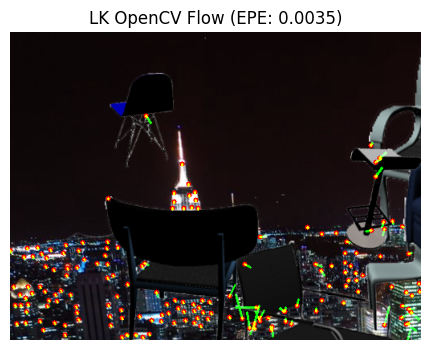

Resultado EPE (Lucas-Kanade OpenCV): 0.0035 píxeles/frame.


In [ ]:
# Carga de datos
gt_flow = read_flow(FLOW_GT_PATH)
img1 = cv2.cvtColor(cv2.imread(str(IMG1_PATH)), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(str(IMG2_PATH)), cv2.COLOR_BGR2RGB)

# Calcular Flujo Lucas-Kanade
flow_pred, img_wiew = lk_flow(img1, img2)

# Usar máscara para comparar solo los puntos predichos
flow_gt_masked = gt_flow.copy()
flow_gt_masked[flow_pred[:, :, 0] == 0] = 0
flow_gt_masked[flow_pred[:, :, 1] == 0] = 0

# Calcular EPE
epe = get_epe(flow_pred, flow_gt_masked) 

display = cv2.cvtColor(img_wiew, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 4))
plt.imshow(display)
plt.title(f"LK OpenCV Flow (EPE: {epe:.4f})")
plt.axis('off')
plt.show()

print(f"Resultado EPE (Lucas-Kanade OpenCV): {epe:.4f} píxeles/frame.")